In [2]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import cm
import json
import seaborn as sns
import plot_utils
import glob
from scipy.optimize import curve_fit
from scipy import special

In [3]:
sns.set_palette("rocket")

In [4]:
colors = sns.color_palette("rocket", n_colors=10)

In [5]:
devices = ['LMG365', 'LMG405', 'LMG450', 'LMG520', 'KAPU405', 'KAPU465']

In [6]:
pocam = '012'
hem = '17'

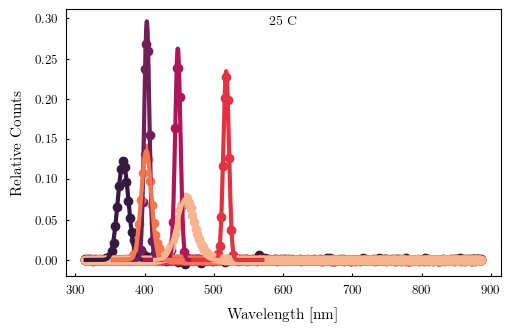

In [7]:
for device in devices:
    path = f'../output/batch2/pocam_{pocam}/hem_{hem}/{device}/spec_25C.json'
    with open(path, 'r') as f:
        data = json.load(f)

    vals = data['meas_data'][0]
    wl_fit = np.linspace(vals['fit_x_min'], vals['fit_x_max'], vals['fit_n_points'])
    plt.scatter(vals['x_values'], vals['y_values'])
    plt.plot(wl_fit, vals['fit_y_values'])
    plt.xlabel(vals['x_label'])
    plt.ylabel(vals['y_label'])
    T = vals['temperature']
    plt.title(f'{T} C')


In [8]:
Temperature=[-40,-30,-20, -10,0, 25 ]

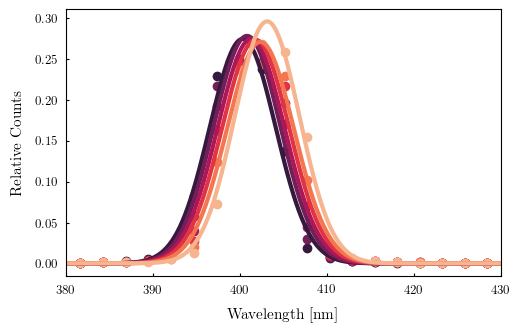

In [9]:
for T in Temperature:
    path = f'../output/batch2/pocam_{pocam}/hem_{hem}/LMG405/spec_{T}C.json'
    with open(path, 'r') as f:
        data = json.load(f)

    vals = data['meas_data'][0]
    wl_fit = np.linspace(vals['fit_x_min'], vals['fit_x_max'], vals['fit_n_points'])
    plt.scatter(vals['x_values'], vals['y_values'])
    plt.plot(wl_fit, vals['fit_y_values'])
    plt.xlabel(vals['x_label'])
    plt.ylabel(vals['y_label'])
    plt.xlim(380,430)
#     Temp = vals['temperature']
#     plt.title(f'{Temp} C')


In [10]:
def gaussian(x, mean, sigma):
    return 1 / (np.sqrt(2 * np.pi) * sigma) * np.exp(-0.5 * ((x - mean) / sigma) ** 2)


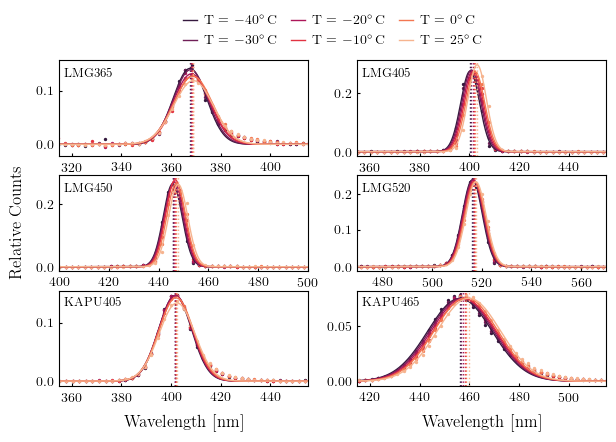

In [11]:
def gaussian(x, amplitude, mean, sigma):
    return amplitude * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

fig, axes = plt.subplots(3,2,figsize=plot_utils.set_size('wide', fraction=1,ratio = 0.4, subplots=(3, 2)))
for i, ax in enumerate(axes.flat):
    device = devices[i]
    for j, T in enumerate(Temperature):
        photons_temp = []
        if "LMG" in device:
            path = f'../output/batch2/pocam_{pocam}/hem_{hem}/{device}/spec_{T:.0f}C.json'
        elif "KAPU" in device:
            path = f'../output/batch2/pocam_{pocam}/hem_{hem}/{device}/spec_{T:.0f}C.json'

        with open(path, 'r') as f:
            data = json.load(f)

        vals = data['meas_data'][0]
        fwhm = data['meas_data'][1]
        cwl = data['meas_data'][2]        
        wl_fit = np.linspace(vals['fit_x_min'], vals['fit_x_max'], vals['fit_n_points'])
        ax.scatter(vals['x_values'], vals['y_values'], s = 2)
        fit, cov = curve_fit(gaussian, vals['x_values'], vals['y_values'], 
                             p0 = [np.amax(vals['y_values']),  
                                   np.mean(vals['x_values']), 
                                   np.std(vals['x_values'])],
                             bounds=([0, np.amin(vals['x_values']), 0], 
                                     [np.inf, np.amax(vals['x_values']), np.inf]),
                             maxfev=10000)
        ax.plot(wl_fit, gaussian(wl_fit, *fit), lw=1, label = f'T = ${T}^\circ\,$C')
        ax.axvline(fit[1], c = f'C{j}', lw =1, ls = ':')
        ax.set_xlim(vals['fit_x_min'], vals['fit_x_max'])
    if i == 2:
        ax.set_ylabel(vals['y_label'])
    if i == 0:
        ax.legend(frameon = False,loc = 'upper center',
                  bbox_to_anchor = (1.1,1.6), ncols = len(Temperature)/2,columnspacing=1.0)
    if i in [4,5]:
        ax.set_xlabel(vals['x_label'])
    ax.text(0.02,0.83, f'{device}', transform = ax.transAxes, size = 9)
    
plt.savefig(f'plots/pdf/spectrum_all_defalut_settings_allT_pocam{pocam}_hem{hem}_gauss_fit.pdf')
plt.savefig(f'plots/png/spectrum_all_defalut_settings_allT_pocam{pocam}_hem{hem}_gauss_fit.png')

In [12]:
from scipy.interpolate import UnivariateSpline

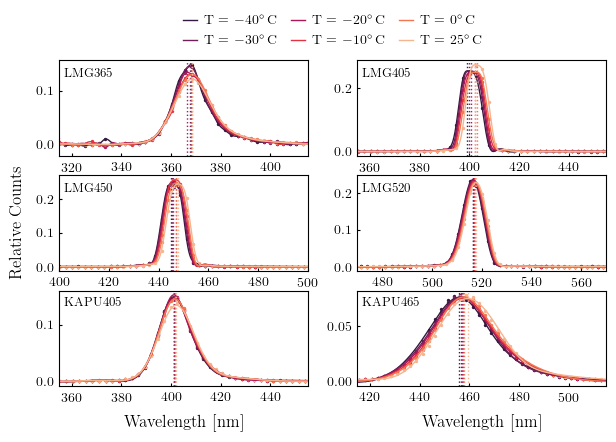

In [13]:
def gaussian(x, amplitude, mean, sigma):
    return amplitude * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

fig, axes = plt.subplots(3,2,figsize=plot_utils.set_size('wide', fraction=1,ratio = 0.4, subplots=(3, 2)))
for i, ax in enumerate(axes.flat):
    device = devices[i]
    wl = int(device[-3:])
    for j, T in enumerate(Temperature):
        photons_temp = []
        if "LMG" in device:
            path = f'../output/batch2/pocam_{pocam}/hem_{hem}/{device}/spec_{T:.0f}C.json'
        elif "KAPU" in device:
            path = f'../output/batch2/pocam_{pocam}/hem_{hem}/{device}/spec_{T:.0f}C.json'

        with open(path, 'r') as f:
            data = json.load(f)

        vals = data['meas_data'][0]
        fwhm = data['meas_data'][1]
        cwl = data['meas_data'][2]        
        
        x =  vals['x_values']
        y = vals['y_values']

        spline = UnivariateSpline(x, y, s=0.0001, k =5)

        spec_lspace = np.linspace(wl-50,wl+50, 1000)

        ax.scatter(x, y, s = 2)
        ax.plot(spec_lspace, spline(spec_lspace), lw=1, label = f'T = ${T}^\circ\,$C')

        idx = np.argmax(spline(spec_lspace))
        peak = spec_lspace[idx]
        ax.axvline(peak, c = f'C{j}', lw =1, ls = ':')

        ax.set_xlim(spec_lspace[0], spec_lspace[-1])

    if i == 2:
        ax.set_ylabel(vals['y_label'])
    if i == 0:
        ax.legend(frameon = False,loc = 'upper center',
                  bbox_to_anchor = (1.1,1.6), ncols = len(Temperature)/2,columnspacing=1.0)
    if i in [4,5]:
        ax.set_xlabel(vals['x_label'])
    ax.text(0.02,0.83, f'{device}', transform = ax.transAxes, size = 9)
    
plt.savefig(f'plots/pdf/spectrum_all_defalut_settings_allT_pocam{pocam}_hem{hem}_spline.pdf')
plt.savefig(f'plots/png/spectrum_all_defalut_settings_allT_pocam{pocam}_hem{hem}_spline.png')

In [14]:
def gaussian(x, amplitude, mean, sigma):
    return amplitude * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

wavelengths_dict_patrick={}
wavelengths_dict_elena={}
wavelengths_dict_spline={}

for device in devices:
    for j, T in enumerate(Temperature):
        wavelengths_dict_patrick[f'{device}_{T}'] = []
        wavelengths_dict_elena[f'{device}_{T}'] = []
        wavelengths_dict_spline[f'{device}_{T}'] = []
        if "LMG" in device:
            filenames_1 = f'../output/batch2/pocam_*/hem_*/{device}/spec_{T:.0f}C_1_20.json'
            filenames_2 = f'../output/batch1/pocam_*/hem_*/{device}/spec_{T:.0f}C_2_20.json'
            filelist_1 = glob.glob(filenames_1)
            filelist_2 = glob.glob(filenames_2)
            filelist = np.concatenate((filelist_1, filelist_2))
        elif "KAPU" in device:
            filenames = f'../output/batch*/pocam_*/hem_*/{device}/spec_{T:.0f}C_default.json'
            filelist = glob.glob(filenames)
        
        for f in filelist:
            with open(f, 'r') as f:
                data = json.load(f)

            vals = data['meas_data'][0]
            fwhm = data['meas_data'][1]
            cwl = data['meas_data'][2]

            wl_fit = np.linspace(vals['fit_x_min'], vals['fit_x_max'], vals['fit_n_points'])

            fit, cov = curve_fit(gaussian, vals['x_values'], vals['y_values'], 
                                 p0 = [np.amax(vals['y_values']),  
                                       np.mean(vals['x_values']), 
                                       np.std(vals['x_values'])],
                                 bounds=([0, np.amin(vals['x_values']), 0], 
                                         [np.inf, np.amax(vals['x_values']), np.inf]),
                                 maxfev=10000)

            spline = UnivariateSpline(vals['x_values'], vals['y_values'], s=0.0001, k =5)
            spec_lspace = np.linspace(vals['fit_x_min'], vals['fit_x_max'], 1000)
            idx = np.argmax(spline(spec_lspace))
            peak = spec_lspace[idx]

            wavelengths_dict_patrick[f'{device}_{T}'].append(cwl['value'])
            wavelengths_dict_elena[f'{device}_{T}'].append(fit[1])
            wavelengths_dict_spline[f'{device}_{T}'].append(peak)


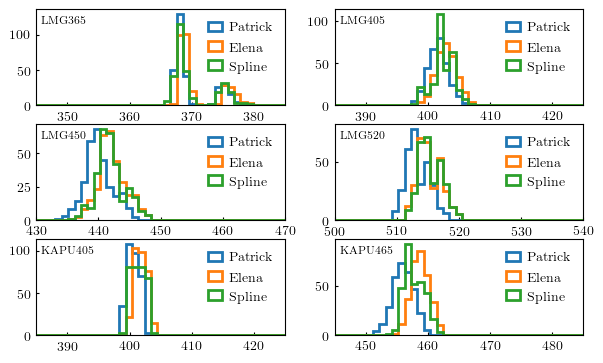

In [14]:
fig, axes = plt.subplots(3,2,figsize=plot_utils.set_size('wide', fraction=1,ratio = 0.4, subplots=(3, 2)))

for i, ax in enumerate(axes.flat):
    device = devices[i]
    wavelengths_dict_patrick_tot = np.concatenate([wavelengths_dict_patrick[f'{device}_{T}'] for T in Temperature])
    wavelengths_dict_elena_tot = np.concatenate([wavelengths_dict_elena[f'{device}_{T}'] for T in Temperature])
    wavelengths_dict_spline_tot = np.concatenate([wavelengths_dict_spline[f'{device}_{T}'] for T in Temperature])
    wl = int(device[-3:])
    bins = np.linspace(wl-20, wl+20, 40)
    ax.hist(wavelengths_dict_patrick_tot, bins = bins, histtype = 'step', color = 'tab:blue', lw = 2, label = 'Patrick')
    ax.hist(wavelengths_dict_elena_tot, bins = bins, histtype = 'step',color = 'tab:orange', lw = 2, label = 'Elena')
    ax.hist(wavelengths_dict_spline_tot, bins = bins, histtype = 'step', color = 'tab:green',lw = 2, label = 'Spline')
    ax.legend()
    ax.text(0.02,0.85, device, transform = ax.transAxes, size = 8)
    ax.set_xlim(wl-20,wl+20)

plt.savefig(f'plots/png/compare_maxima.png')
    

In [26]:
Temperature = [-40,-30,-20, -10,0, 25 ]

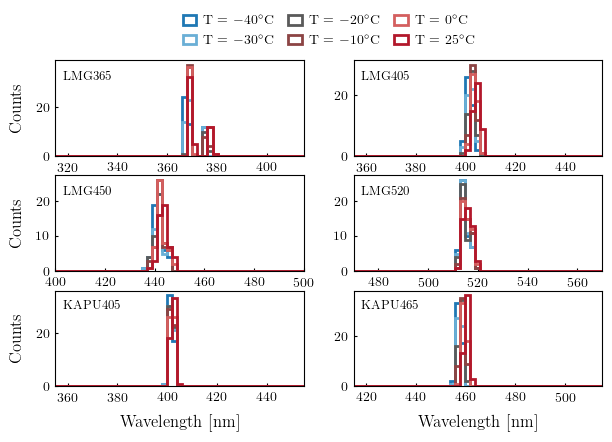

In [18]:
#make plot with 6 panels and plot one histo per each panel

fig, axes = plt.subplots(3,2,figsize=plot_utils.set_size('wide', fraction=1,ratio = 0.4, subplots=(3, 2)))
colors = [
    '#1f78b4',  # deep blue       → -40°C
    '#6aafd6',  # light blue      → -25°C
    '#5a5a5a',  # dark grey       → -10°C
    '#8c4444',  # dark muted red  →   5°C  (transition through grey keeps this dark)
    '#d45f5f',  # medium red      →  15°C
    '#b2182b',  # deep red        →  25°C
]

for i, ax in enumerate(axes.flat):
    device = devices[i]
    wl = int(device[-3:])

    tot_wl_elena = np.concatenate([wavelengths_dict_elena[f'{device}_{T}'] for T in Temperature])
    # tot_wl_patrick= np.concatenate([wavelengths_dict_patrick[f'{device}_{T}'] for T in Temperature])
    bins = np.linspace(wl-50,wl+50, 50)
    for j, T in enumerate(Temperature):
        ax.hist(wavelengths_dict_elena[f'{device}_{T}'] , bins, histtype = 'step', color = colors[j], lw =2, label = f'T = ${T}^\circ$C ')
        mean_wl = np.mean(wavelengths_dict_elena[f'{device}_{T}'])
        ax.set_xlim(mean_wl-15, mean_wl+15)
    ax.text(0.03,0.8, f'{device}', transform = ax.transAxes, size = 9)
    ax.set_xlim(wl-50, wl+50)
    # ax.axvline(wl, ls = ':', color = 'k', lw = 1, label = 'Nominal Wavelength')
    # ax.axvline(wl, ls = ':', color = 'k', lw = 1, label = 'Nominal Wavelength')
    if i == 0:
        ax.legend(frameon = False,loc = 'upper center',
                bbox_to_anchor = (1.1,1.6), ncols = len(Temperature)/2,columnspacing=1.0)
    if np.isin(i, [4,5]):
        ax.set_xlabel('Wavelength [nm]')
    
    if np.isin(i, [0,2,4]):
        ax.set_ylabel('Counts')
    # ax.axvline(np.median(tot_wl_elena), ls = ':', color = 'k')

plt.savefig('plots/pdf/wavelength_hist_all_defalut_settings_allT_allPocams.pdf')
plt.savefig('plots/png/wavelength_hist_all_defalut_settings_allT_allPocams.png')

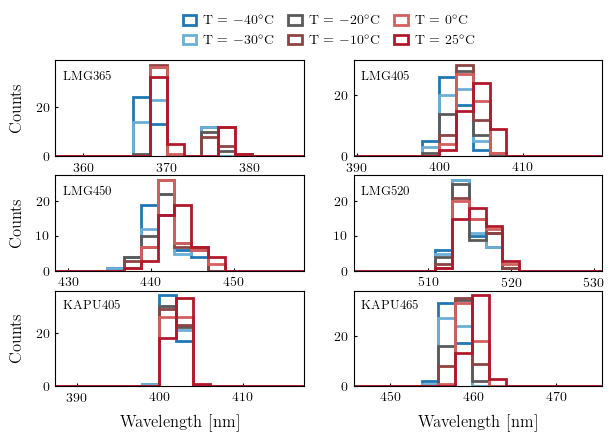

In [19]:
#make plot with 6 panels and plot one histo per each panel

fig, axes = plt.subplots(3,2,figsize=plot_utils.set_size('wide', fraction=1,ratio = 0.4, subplots=(3, 2)))


for i, ax in enumerate(axes.flat):
    device = devices[i]
    wl = int(device[-3:])

    tot_wl_elena = np.concatenate([wavelengths_dict_elena[f'{device}_{T}'] for T in Temperature])
    # tot_wl_patrick= np.concatenate([wavelengths_dict_patrick[f'{device}_{T}'] for T in Temperature])
    bins = np.linspace(wl-50,wl+50, 50)
    for j, T in enumerate(Temperature):
        ax.hist(wavelengths_dict_elena[f'{device}_{T}'] , bins, histtype = 'step', color = colors[j], lw =2, label = f'T = ${T}^\circ$C ')
        mean_wl = np.mean(wavelengths_dict_elena[f'{device}_{T}'])
    ax.set_xlim(mean_wl-15, mean_wl+15)
    ax.text(0.03,0.8, f'{device}', transform = ax.transAxes, size = 9)
    # ax.set_xlim(wl-50, wl+50)
    # ax.axvline(wl, ls = ':', color = 'k', lw = 1, label = 'Nominal Wavelength')
    # ax.axvline(wl, ls = ':', color = 'k', lw = 1, label = 'Nominal Wavelength')
    if i == 0:
        ax.legend(frameon = False,loc = 'upper center',
                bbox_to_anchor = (1.1,1.6), ncols = len(Temperature)/2,columnspacing=1.0)
    if np.isin(i, [4,5]):
        ax.set_xlabel('Wavelength [nm]')
    
    if np.isin(i, [0,2,4]):
        ax.set_ylabel('Counts')
    # ax.axvline(np.median(tot_wl_elena), ls = ':', color = 'k')

plt.savefig('plots/pdf/wavelength_hist_all_defalut_settings_allT_allPocams.pdf')
plt.savefig('plots/png/wavelength_hist_all_defalut_settings_allT_allPocams.png')

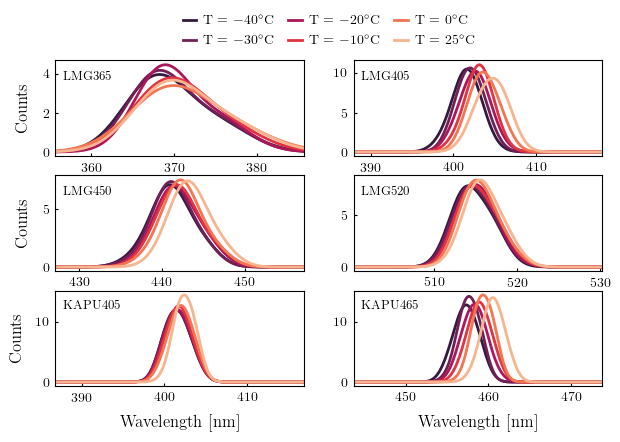

In [16]:
from scipy.stats import gaussian_kde

sns.set_palette("rocket")

fig, axes = plt.subplots(3, 2, figsize=plot_utils.set_size('wide', fraction=1, ratio=0.4, subplots=(3, 2)))

for i, ax in enumerate(axes.flat):
    device = devices[i]
    wl = int(device[-3:])

    mean_wl = np.mean([np.mean(wavelengths_dict_elena[f'{device}_{T}']) for T in Temperature])
    xlo, xhi = mean_wl - 15, mean_wl + 15
    bins = np.linspace(xlo, xhi, 20)
    x_eval = np.linspace(xlo, xhi, 200)

    for j, T in enumerate(Temperature):
        vals = wavelengths_dict_elena[f'{device}_{T}']
        color = f'C{j}'  # keeps your original matplotlib default colors

        counts, edges = np.histogram(vals, bins=bins)
        bin_centers = 0.5 * (edges[:-1] + edges[1:])

        mask = counts > 0
        kde = gaussian_kde(bin_centers[mask], bw_method='scott', weights=counts[mask])
        y_kde = kde(x_eval) * len(vals)

        ax.plot(x_eval, y_kde, lw=2, color=color, label=f'T = ${T}^\\circ$C ')
        # ax.fill_between(x_eval, y_kde, alpha=0.2, color=color)

    ax.set_xlim(xlo, xhi)
    ax.text(0.03, 0.8, f'{device}', transform=ax.transAxes, size=9)

    if i == 0:
        ax.legend(frameon=False, loc='upper center',
                  bbox_to_anchor=(1.1, 1.6), ncols=len(Temperature)/2, columnspacing=1.0)
    if np.isin(i, [4, 5]):
        ax.set_xlabel('Wavelength [nm]')
    if np.isin(i, [0, 2, 4]):
        ax.set_ylabel('Counts')

plt.savefig('plots/pdf/wavelength_hist_all_defalut_settings_allT_allPocams.pdf')
plt.savefig('plots/png/wavelength_hist_all_defalut_settings_allT_allPocams.png')

In [17]:
Temperature=[-40,-30,-20]

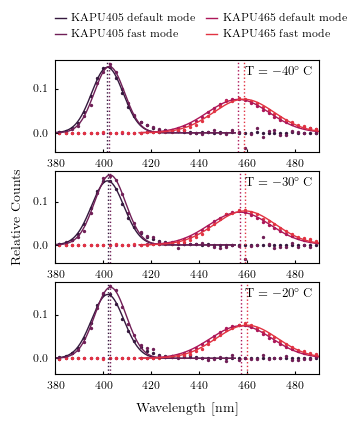

In [18]:
def gaussian(x, amplitude, mean, sigma):
    return amplitude * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

fig, axes = plt.subplots(3,1,figsize=plot_utils.set_size('colums', fraction=1,ratio = 0.4, subplots=(3, 1)))
for i, ax in enumerate(axes.flat):
    j = -1 
    T = Temperature[i]
    for kapu in ['KAPU405', 'KAPU465']:
        for mode in ['default','fast']:
            path = f'../output/batch2/pocam_{pocam}/hem_{hem}/{kapu}/spec_{T:.0f}C_{mode}.json'
            j = j+1
            with open(path, 'r') as f:
                data = json.load(f)
            
            label = f'{kapu} {mode} mode'
            
            vals = data['meas_data'][0]
            fwhm = data['meas_data'][1]
            cwl = data['meas_data'][2]        
            wl_fit = np.linspace(vals['fit_x_min'], vals['fit_x_max'], vals['fit_n_points'])
            ax.scatter(vals['x_values'], vals['y_values'], s = 2)
            fit, cov = curve_fit(gaussian, vals['x_values'], vals['y_values'], 
                                 p0 = [np.amax(vals['y_values']),  
                                       np.mean(vals['x_values']), 
                                       np.std(vals['x_values'])],
                                 bounds=([0, np.amin(vals['x_values']), 0], 
                                         [np.inf, np.amax(vals['x_values']), np.inf]),
                                 maxfev=10000)
            ax.plot(wl_fit, gaussian(wl_fit, *fit), lw=1, label = label)
            ax.axvline(fit[1], c = f'C{j}', lw =1, ls = ':')
            ax.set_xlim(380, 490)
# if i == 2:
#     ax.set_ylabel(vals['y_label'])
    if i == 0:
        ax.legend(frameon = False,loc = 'upper center',
              bbox_to_anchor = (.55,1.6), ncols = 2,columnspacing=1.0)
    if i ==2:
        ax.set_xlabel(vals['x_label'])
    if i ==1:
        ax.set_ylabel(vals['y_label'])
    
    ax.text(0.72,0.83, f'T = ${T}^\circ\,$C', transform = ax.transAxes, size = 9)
    
plt.savefig('plots/pdf/spectrum_kapu_defalut_fast_allT_pocam{pocam}_hem{hem}.pdf')
plt.savefig('plots/png/spectrum_kapu_defalut_fast_allT_pocam{pocam}_hem{hem}.png')

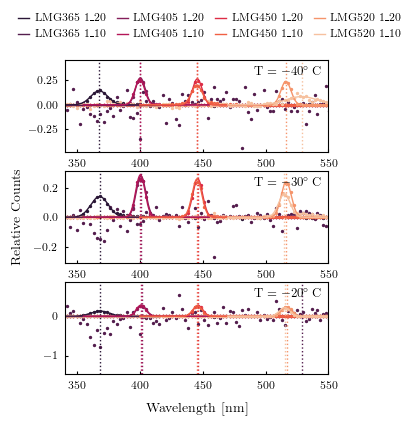

In [19]:
def gaussian(x, amplitude, mean, sigma):
    return amplitude * np.exp(-0.5 * ((x - mean) / sigma) ** 2)
colors = sns.color_palette("rocket", n_colors=8)
fig, axes = plt.subplots(3,1,figsize=plot_utils.set_size('colums', fraction=1,ratio = 0.4, subplots=(3, 1)))
for i, ax in enumerate(axes.flat):
    j = -1 
    T = Temperature[i]
    for lmg in ['LMG365', 'LMG405', 'LMG450', 'LMG520']:
        for coarse_fine in ['1_20', '1_10']:
            path = f'../output/batch2/pocam_{pocam}/hem_{hem}/{lmg}/spec_{T:.0f}C_{coarse_fine}.json'
            j = j+1
            with open(path, 'r') as f:
                data = json.load(f)
            
            label = f'{lmg} {coarse_fine}'
            
            vals = data['meas_data'][0]
            fwhm = data['meas_data'][1]
            cwl = data['meas_data'][2]        
            wl_fit = np.linspace(vals['fit_x_min'], vals['fit_x_max'], vals['fit_n_points'])
            ax.scatter(vals['x_values'], vals['y_values'], s = 2, color = colors[j])
            fit, cov = curve_fit(gaussian, vals['x_values'], vals['y_values'], 
                                 p0 = [np.amax(vals['y_values']),  
                                       np.mean(vals['x_values']), 
                                       np.std(vals['x_values'])],
                                 bounds=([0, np.amin(vals['x_values']), 0], 
                                         [np.inf, np.amax(vals['x_values']), np.inf]),
                                 maxfev=10000)
            ax.plot(wl_fit, gaussian(wl_fit, *fit), lw=1, label = label, color = colors[j])
            ax.axvline(fit[1], c = colors[j], lw =1, ls = ':')
            ax.set_xlim(340, 550)
# if i == 2:
#     ax.set_ylabel(vals['y_label'])
    if i == 0:
        ax.legend(frameon = False,loc = 'upper center',
              bbox_to_anchor = (.55,1.6), ncols = 4,columnspacing=1.0)
    if i ==2:
        ax.set_xlabel(vals['x_label'])
    if i ==1:
        ax.set_ylabel(vals['y_label'])
    
    ax.text(0.72,0.83, f'T = ${T}^\circ\,$C', transform = ax.transAxes, size = 9)
    
plt.savefig('plots/pdf/spectrum_LMG_different_modes_allT_pocam{pocam}_hem{hem}.pdf')
plt.savefig('plots/png/spectrum_LMG_different_modes_allT_pocam{pocam}_hem{hem}.png')